# MAC vs DR: MPC dense reward, goal guide reward, and success vs K

Read the downloaded `mac_dense_replan` and `dr_dense_replan` runs. Here **H = K**: both planning horizon and maximum action execution block change together; prediction mismatch may trigger early replanning.

Dense reward is the recorded **episode `dense_return`** (the sum of realized dense rewards, without discounting), not the imagined planner score or native environment reward. Success rate is the fraction of successful episodes.

Average episodes and target maps within each WM checkpoint seed, then average the five checkpoint seeds equally. Shading is **±1 sample standard deviation across checkpoint seeds**, not a confidence interval. Target-specific plots average episodes within each checkpoint seed first. Raw returns are shown without length normalization.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import display

REPO_ROOT = next(
    (p for p in (Path.cwd(), *Path.cwd().parents)
     if (p / 'wm').is_dir() and (p / 'trainer').is_dir()),
    None,
)
if REPO_ROOT is None:
    raise FileNotFoundError('Open this notebook from within the project workspace.')
RESULTS = REPO_ROOT / 'test/minigrid_mpc_k_sweep/results'
RUNS = {'MAC': RESULTS / 'mac_dense_replan', 'DR': RESULTS / 'dr_dense_replan'}
COLORS = {'MAC': '#2878B5', 'DR': '#E07A32'}
FIGURE_DIR = REPO_ROOT / 'outputs/jupyter/figures/mpc_dense_mac_vs_dr'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
configs = {label: json.loads((path / 'run_config.json').read_text())
           for label, path in RUNS.items()}
# Compare experimental settings while allowing machine paths and scheduling to differ.
science_keys = [
    'k_values', 'horizon_equals_execute_steps', 'episodes', 'eval_seed',
    'max_ep_len', 'reward_mode', 'goal_guide_weight', 'population',
    'elite_count', 'iterations', 'gamma', 'stop_on_prediction_mismatch',
    'skip_attention_weights',
]
for key in science_keys:
    if configs['MAC'].get(key) != configs['DR'].get(key):
        raise ValueError(f'MAC and DR settings differ: {key}')
map_hashes = {label: {k: v['layout_sha256'] for k, v in cfg['targets'].items()}
              for label, cfg in configs.items()}
if map_hashes['MAC'] != map_hashes['DR']:
    raise ValueError('MAC and DR target maps differ.')

frames, coverage_rows = [], []
for label, path in RUNS.items():
    cfg = configs[label]
    data = pd.read_csv(path / 'episode_results.csv')
    expected_baseline = label.lower()
    if not data['baseline'].eq(expected_baseline).all():
        raise ValueError(f'{label}: unexpected baseline in episode CSV')
    if cfg['reward_mode'] != 'legacy_dense' or not data['reward_mode'].eq('legacy_dense').all():
        raise ValueError(f'{label}: expected legacy_dense reward mode')
    if not cfg['horizon_equals_execute_steps'] or not data['horizon'].eq(data['execute_steps']).all():
        raise ValueError(f'{label}: expected H = K')
    if not data['eval_seed'].eq(cfg['eval_seed']).all():
        raise ValueError(f'{label}: evaluation seed differs from run configuration')
    data['success'] = data['success'].astype(str).str.lower().map({'true': 1.0, 'false': 0.0})
    if data['success'].isna().any() or not np.isfinite(data['dense_return']).all():
        raise ValueError(f'{label}: invalid success or dense return values')
    identities = ['model_id', 'target_id', 'horizon', 'episode']
    expected = pd.MultiIndex.from_product(
        [[m['model_id'] for m in cfg['models']],
         [int(t) for t in cfg['targets']], cfg['k_values'], range(cfg['episodes'])],
        names=identities,
    )
    actual = pd.MultiIndex.from_frame(data[identities])
    missing, unexpected = expected.difference(actual), actual.difference(expected)
    if actual.has_duplicates or len(missing) or len(unexpected):
        raise ValueError(f'{label}: incomplete/invalid coverage: '
                         f'{len(missing)} missing, {len(unexpected)} unexpected episodes; '
                         f'duplicates={actual.has_duplicates}')
    data['Baseline'] = label
    data['K'] = data['horizon']
    frames.append(data)
    coverage_rows.append({'Baseline': label, 'Episodes': len(data),
                          'WM seeds': data['model_id'].nunique(),
                          'Targets': data['target_id'].nunique(),
                          'K values': sorted(data['K'].unique().tolist()),
                          'Reward mode': cfg['reward_mode'],
                          'Early replan on mismatch': cfg.get('stop_on_prediction_mismatch', False)})
episodes = pd.concat(frames, ignore_index=True)
K_VALUES = configs['MAC']['k_values']
display(pd.DataFrame(coverage_rows).set_index('Baseline'))


,Episodes,WM seeds,Targets,K values,Reward mode,Early replan on mismatch
Baseline,,,,,,
MAC,2000,5,5,"[8, 16, 32, 40, 48, 56, 64, 80]",legacy_dense,True
DR,2000,5,5,"[8, 16, 32, 40, 48, 56, 64, 80]",legacy_dense,True


,Baseline,K,dense_mean,dense_std,success_mean,success_std,n_seeds
0,DR,8,63.999,0.003,100.0%,0.0%,5
1,DR,16,63.890,0.019,100.0%,0.0%,5
2,DR,32,63.032,0.925,98.4%,1.7%,5
3,DR,40,63.333,0.549,99.2%,1.1%,5
4,DR,48,59.031,2.824,90.8%,5.4%,5
5,DR,56,42.392,1.949,58.4%,3.8%,5
6,DR,64,24.199,3.155,23.6%,6.2%,5
7,DR,80,10.800,0.546,0.8%,1.1%,5
8,MAC,8,63.775,0.484,99.6%,0.9%,5
9,MAC,16,63.903,0.007,100.0%,0.0%,5


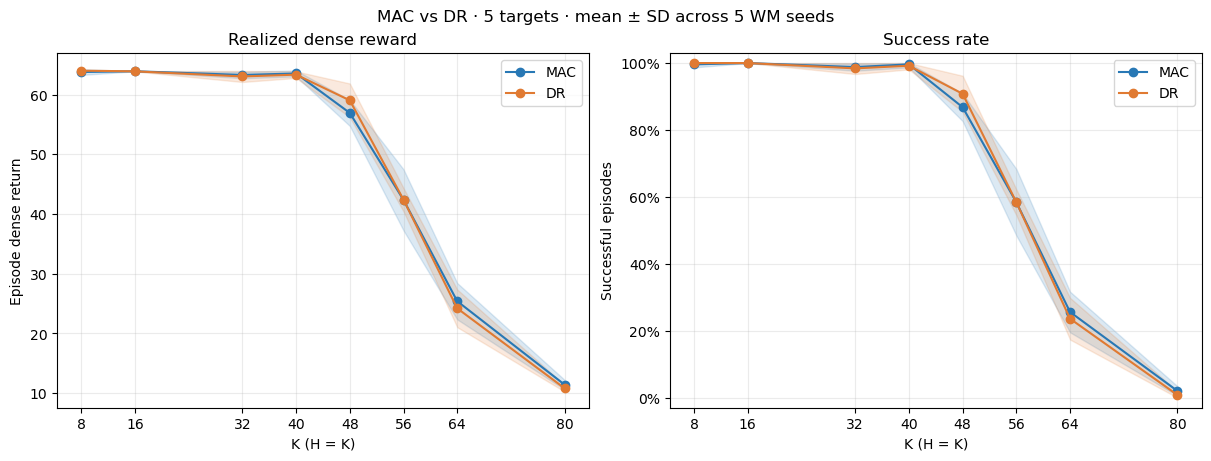

In [3]:
# Each checkpoint seed contributes equally; episodes are not treated as independent model seeds.
seed_means = episodes.groupby(['Baseline', 'model_id', 'K'], as_index=False).agg(
    dense_return=('dense_return', 'mean'), success_rate=('success', 'mean'))
summary = seed_means.groupby(['Baseline', 'K'], as_index=False).agg(
    dense_mean=('dense_return', 'mean'), dense_std=('dense_return', 'std'),
    success_mean=('success_rate', 'mean'), success_std=('success_rate', 'std'),
    n_seeds=('model_id', 'nunique'))
display(summary.style.format({'dense_mean': '{:.3f}', 'dense_std': '{:.3f}',
                             'success_mean': '{:.1%}', 'success_std': '{:.1%}'}))
summary.to_csv(FIGURE_DIR / 'summary_by_k.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
for ax, mean, std, title, ylabel in [
    (axes[0], 'dense_mean', 'dense_std', 'Realized dense reward', 'Episode dense return'),
    (axes[1], 'success_mean', 'success_std', 'Success rate', 'Successful episodes'),
]:
    for label in RUNS:
        part = summary[summary['Baseline'].eq(label)].sort_values('K')
        x, y, spread = (part[col].to_numpy() for col in ['K', mean, std])
        ax.plot(x, y, marker='o', color=COLORS[label], label=label)
        lower, upper = y - spread, y + spread
        if mean == 'success_mean':
            lower, upper = np.clip(lower, 0, 1), np.clip(upper, 0, 1)
        ax.fill_between(x, lower, upper, color=COLORS[label], alpha=0.16)
    ax.set(title=title, xlabel='K (H = K)', ylabel=ylabel, xticks=K_VALUES)
    ax.grid(alpha=0.25)
    ax.legend()
axes[1].set_ylim(-0.03, 1.03)
axes[1].yaxis.set_major_formatter(PercentFormatter(1))
fig.suptitle('MAC vs DR · 5 targets · mean ± SD across 5 WM seeds')
fig.savefig(FIGURE_DIR / 'overall.png', dpi=200, bbox_inches='tight')
fig.savefig(FIGURE_DIR / 'overall.pdf', bbox_inches='tight')
plt.show()


## Results per target map

The same metrics and checkpoint-seed aggregation, split by target. Success bands are clipped to [0, 1] for display only; the table retains the original standard deviation.


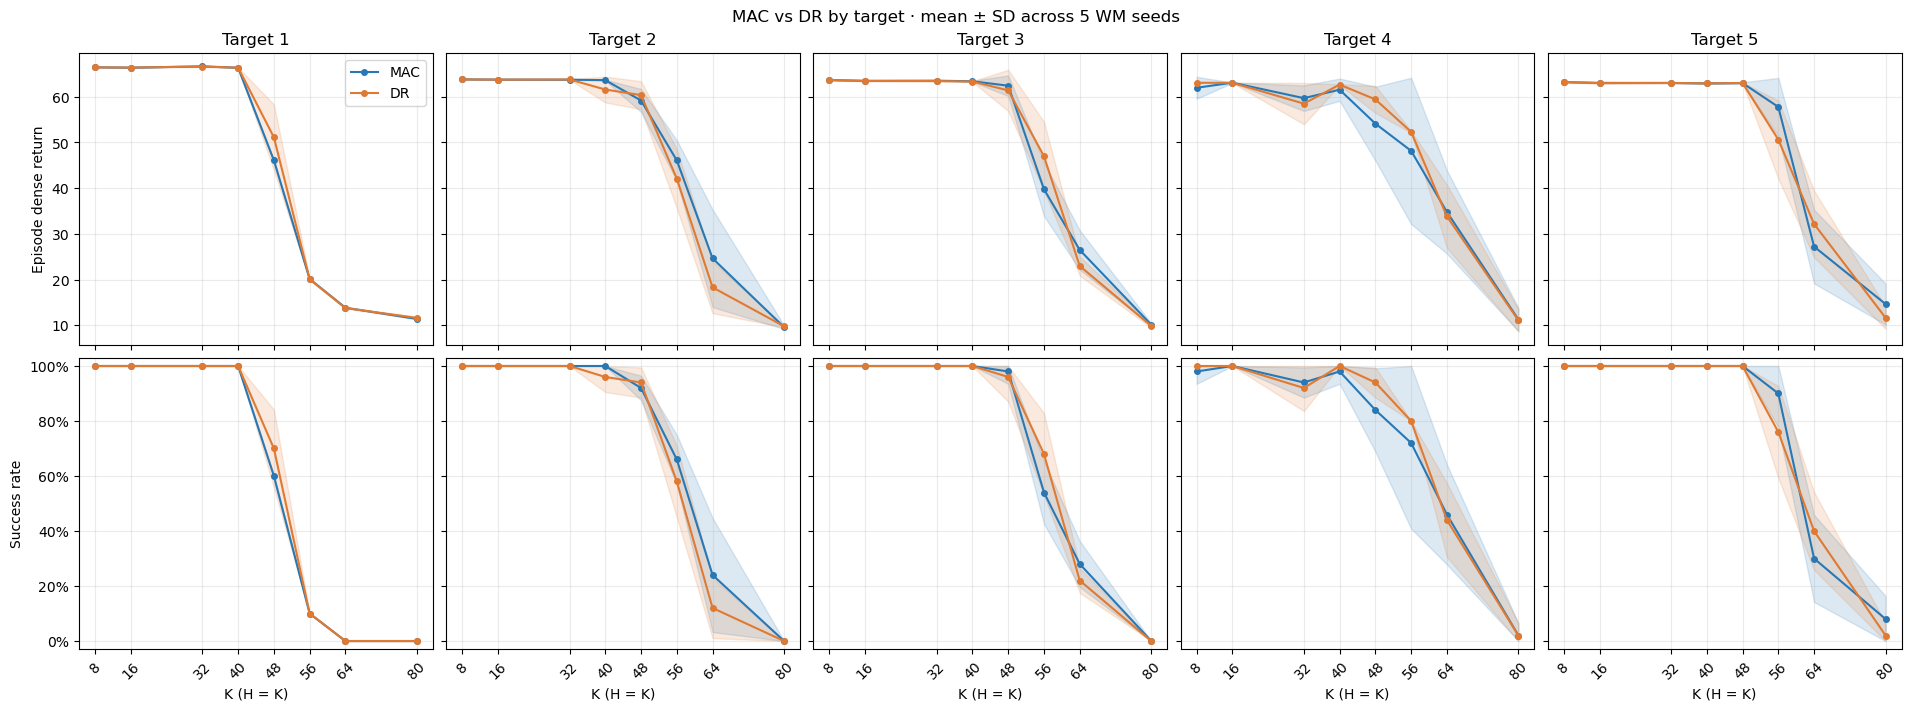

Figures and summary CSVs saved to: outputs/jupyter/figures/mpc_dense_mac_vs_dr


In [4]:
target_seed_means = episodes.groupby(
    ['Baseline', 'model_id', 'target_id', 'K'], as_index=False
).agg(dense_return=('dense_return', 'mean'), success_rate=('success', 'mean'))
target_summary = target_seed_means.groupby(['Baseline', 'target_id', 'K'], as_index=False).agg(
    dense_mean=('dense_return', 'mean'), dense_std=('dense_return', 'std'),
    success_mean=('success_rate', 'mean'), success_std=('success_rate', 'std'))
target_summary.to_csv(FIGURE_DIR / 'summary_by_target_k.csv', index=False)
target_ids = sorted(episodes['target_id'].unique())
fig, axes = plt.subplots(2, len(target_ids), figsize=(19, 7), sharex=True,
                         sharey='row', squeeze=False, constrained_layout=True)
for col, target_id in enumerate(target_ids):
    for row, (mean, std) in enumerate([('dense_mean', 'dense_std'), ('success_mean', 'success_std')]):
        ax = axes[row, col]
        for label in RUNS:
            part = target_summary[
                target_summary['Baseline'].eq(label) & target_summary['target_id'].eq(target_id)
            ].sort_values('K')
            x, y, spread = (part[key].to_numpy() for key in ['K', mean, std])
            ax.plot(x, y, marker='o', markersize=4, color=COLORS[label], label=label)
            lower, upper = y - spread, y + spread
            if row == 1:
                lower, upper = np.clip(lower, 0, 1), np.clip(upper, 0, 1)
            ax.fill_between(x, lower, upper, color=COLORS[label], alpha=0.16)
        ax.set_xticks(K_VALUES)
        ax.tick_params(axis='x', rotation=45)
        ax.grid(alpha=0.25)
        if row == 0:
            ax.set_title(f'Target {target_id}')
        else:
            ax.set_xlabel('K (H = K)')
            ax.set_ylim(-0.03, 1.03)
            ax.yaxis.set_major_formatter(PercentFormatter(1))
axes[0, 0].set_ylabel('Episode dense return')
axes[1, 0].set_ylabel('Success rate')
axes[0, 0].legend()
fig.suptitle('MAC vs DR by target · mean ± SD across 5 WM seeds')
fig.savefig(FIGURE_DIR / 'by_target.png', dpi=200, bbox_inches='tight')
fig.savefig(FIGURE_DIR / 'by_target.pdf', bbox_inches='tight')
plt.show()
print(f'Figures and summary CSVs saved to: {FIGURE_DIR.relative_to(REPO_ROOT)}')


## Goal guide reward on the same recorded trajectories

These runs used **`legacy_dense` for MPC action selection**. The plots below use the separately recorded guide diagnostics; they are **not a new evaluation with `native_goal` planning**. Success rates are therefore unchanged.

- **Realized goal guide return**: `realized_goal_guide_return`, summed over executed action blocks. Each block contributes `weight × clip((start_distance − end_distance) / max(1, start_distance), −1, 1) × gamma^(executed_steps − 1)`. Failed blocks contribute zero. Here weight = 0.05 and gamma = 0.99.
- **Native reward + guide return**: `real_reward_plus_realized_goal_guide`, the recorded native environment reward plus that guide return. This is a diagnostic total, not the imagined planning score.

Means and ±1 sample SD use the same checkpoint-seed aggregation as above. Because the guide is computed per execution block, its accumulated value also depends on block boundaries and early replanning.


,Baseline,K,guide_mean,guide_std,combined_mean,combined_std,success_mean,success_std
0,DR,8,0.1773,0.0005,0.9313,0.0012,100.0%,0.0%
1,DR,16,0.1556,0.0013,0.7780,0.0012,100.0%,0.0%
2,DR,32,0.1303,0.0010,0.5208,0.0095,98.4%,1.7%
3,DR,40,0.1193,0.0030,0.4209,0.0073,99.2%,1.1%
4,DR,48,0.1052,0.0041,0.3099,0.0149,90.8%,5.4%
5,DR,56,0.0815,0.0026,0.1856,0.0083,58.4%,3.8%
6,DR,64,0.0483,0.0035,0.0868,0.0159,23.6%,6.2%
7,DR,80,0.0267,0.0010,0.0278,0.0023,0.8%,1.1%
8,MAC,8,0.1765,0.0021,0.9262,0.0093,99.6%,0.9%
9,MAC,16,0.1543,0.0010,0.7766,0.0052,100.0%,0.0%


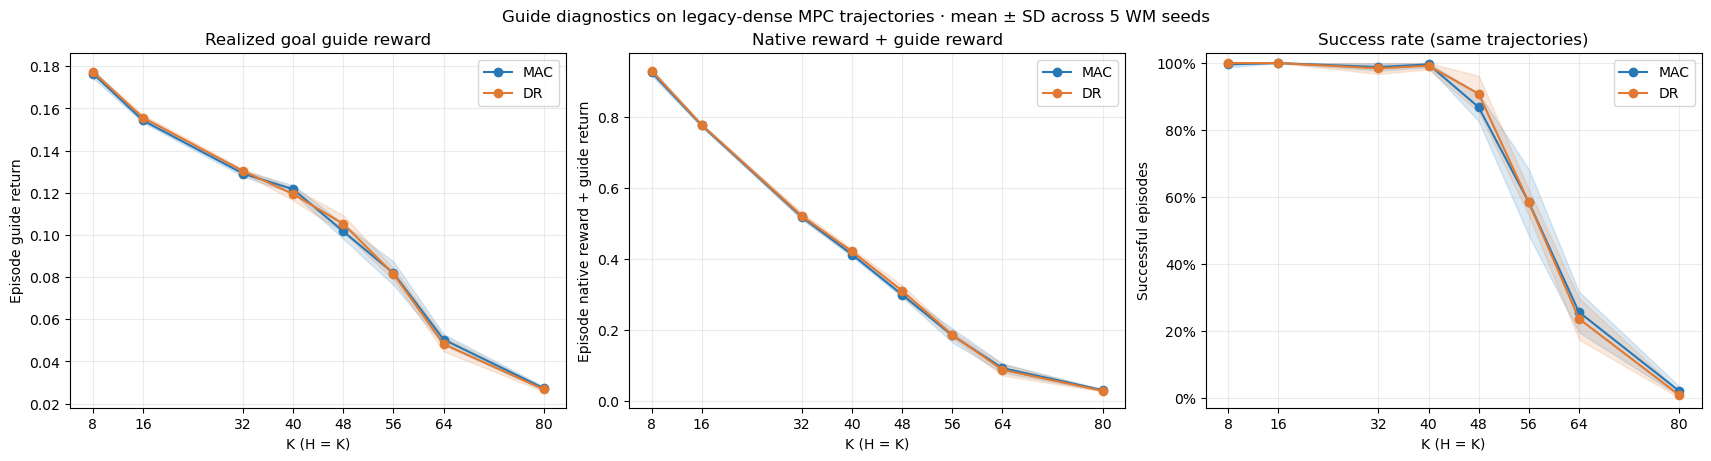

In [5]:
guide_columns = ['realized_goal_guide_return', 'real_reward_plus_realized_goal_guide']
if not np.isfinite(episodes[guide_columns].to_numpy()).all():
    raise ValueError('Invalid recorded guide reward values')
if not np.allclose(episodes['real_reward_plus_realized_goal_guide'],
                   episodes['real_reward'] + episodes['realized_goal_guide_return']):
    raise ValueError('Recorded native reward + guide total is inconsistent')

guide_seed_means = episodes.groupby(['Baseline', 'model_id', 'K'], as_index=False).agg(
    guide=('realized_goal_guide_return', 'mean'),
    combined=('real_reward_plus_realized_goal_guide', 'mean'),
    success=('success', 'mean'))
guide_summary = guide_seed_means.groupby(['Baseline', 'K'], as_index=False).agg(
    guide_mean=('guide', 'mean'), guide_std=('guide', 'std'),
    combined_mean=('combined', 'mean'), combined_std=('combined', 'std'),
    success_mean=('success', 'mean'), success_std=('success', 'std'))
display(guide_summary.style.format({
    'guide_mean': '{:.4f}', 'guide_std': '{:.4f}',
    'combined_mean': '{:.4f}', 'combined_std': '{:.4f}',
    'success_mean': '{:.1%}', 'success_std': '{:.1%}'}))
guide_summary.to_csv(FIGURE_DIR / 'guide_summary_by_k.csv', index=False)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5), constrained_layout=True)
for ax, metric, title, ylabel in [
    (axes[0], 'guide', 'Realized goal guide reward', 'Episode guide return'),
    (axes[1], 'combined', 'Native reward + guide reward', 'Episode native reward + guide return'),
    (axes[2], 'success', 'Success rate (same trajectories)', 'Successful episodes'),
]:
    for label in RUNS:
        part = guide_summary[guide_summary['Baseline'].eq(label)].sort_values('K')
        x, y, spread = (part[key].to_numpy() for key in ['K', f'{metric}_mean', f'{metric}_std'])
        ax.plot(x, y, marker='o', color=COLORS[label], label=label)
        lower, upper = y - spread, y + spread
        if metric == 'success':
            lower, upper = np.clip(lower, 0, 1), np.clip(upper, 0, 1)
        ax.fill_between(x, lower, upper, color=COLORS[label], alpha=0.16)
    ax.set(title=title, xlabel='K (H = K)', ylabel=ylabel, xticks=K_VALUES)
    ax.grid(alpha=0.25)
    ax.legend()
axes[2].set_ylim(-0.03, 1.03)
axes[2].yaxis.set_major_formatter(PercentFormatter(1))
fig.suptitle('Guide diagnostics on legacy-dense MPC trajectories · mean ± SD across 5 WM seeds')
fig.savefig(FIGURE_DIR / 'guide_overall.png', dpi=200, bbox_inches='tight')
fig.savefig(FIGURE_DIR / 'guide_overall.pdf', bbox_inches='tight')
plt.show()


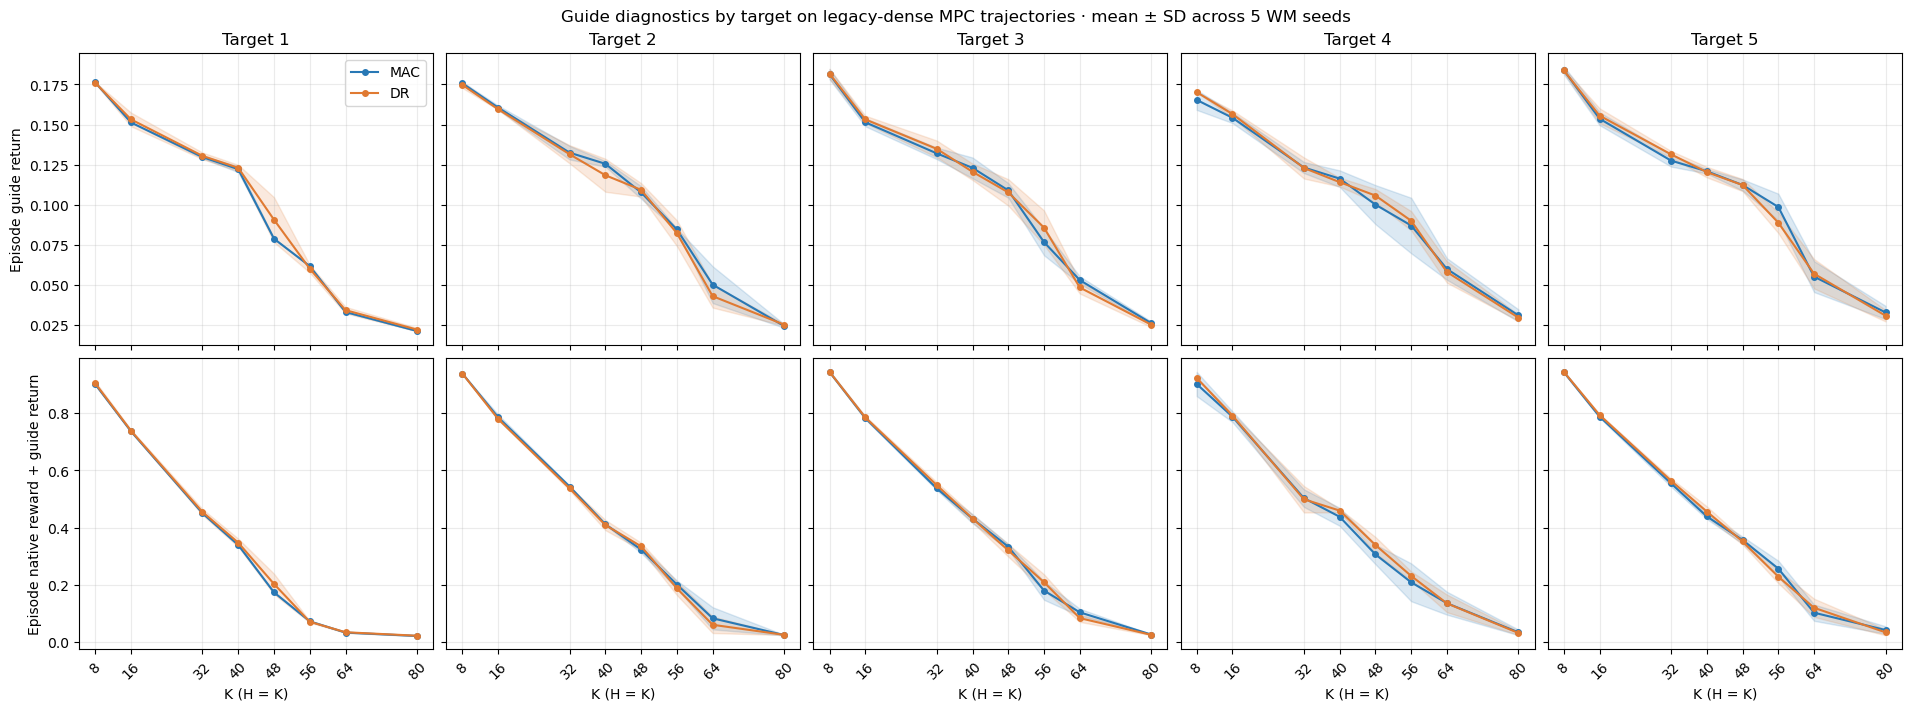

In [6]:
guide_target_seed_means = episodes.groupby(
    ['Baseline', 'model_id', 'target_id', 'K'], as_index=False
).agg(guide=('realized_goal_guide_return', 'mean'),
      combined=('real_reward_plus_realized_goal_guide', 'mean'))
guide_target_summary = guide_target_seed_means.groupby(
    ['Baseline', 'target_id', 'K'], as_index=False
).agg(guide_mean=('guide', 'mean'), guide_std=('guide', 'std'),
      combined_mean=('combined', 'mean'), combined_std=('combined', 'std'))
guide_target_summary.to_csv(FIGURE_DIR / 'guide_summary_by_target_k.csv', index=False)

fig, axes = plt.subplots(2, len(target_ids), figsize=(19, 7), sharex=True,
                         sharey='row', squeeze=False, constrained_layout=True)
for col, target_id in enumerate(target_ids):
    for row, metric in enumerate(['guide', 'combined']):
        ax = axes[row, col]
        for label in RUNS:
            part = guide_target_summary[
                guide_target_summary['Baseline'].eq(label)
                & guide_target_summary['target_id'].eq(target_id)
            ].sort_values('K')
            x, y, spread = (part[key].to_numpy() for key in ['K', f'{metric}_mean', f'{metric}_std'])
            ax.plot(x, y, marker='o', markersize=4, color=COLORS[label], label=label)
            ax.fill_between(x, y - spread, y + spread, color=COLORS[label], alpha=0.16)
        ax.set_xticks(K_VALUES)
        ax.tick_params(axis='x', rotation=45)
        ax.grid(alpha=0.25)
        if row == 0:
            ax.set_title(f'Target {target_id}')
        else:
            ax.set_xlabel('K (H = K)')
axes[0, 0].set_ylabel('Episode guide return')
axes[1, 0].set_ylabel('Episode native reward + guide return')
axes[0, 0].legend()
fig.suptitle('Guide diagnostics by target on legacy-dense MPC trajectories · mean ± SD across 5 WM seeds')
fig.savefig(FIGURE_DIR / 'guide_by_target.png', dpi=200, bbox_inches='tight')
fig.savefig(FIGURE_DIR / 'guide_by_target.pdf', bbox_inches='tight')
plt.show()
